In [1]:

from spm_agent.states.image_analysis_state import AnalysisState
from langgraph.graph import StateGraph, START, END
from spm_agent.config import new_run; new_run("digest_test")

PosixPath('/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/runs/20260716_120404_digest_test')

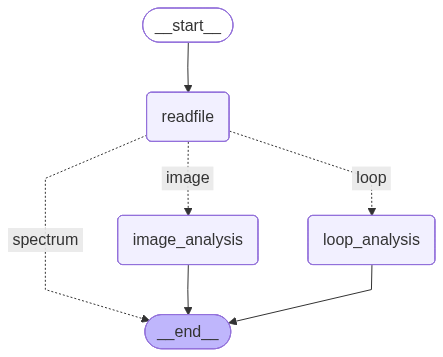

In [2]:
from spm_agent.graphs.analysis_graph import build_analysis_graph

EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    "Compare switching inside domains vs near domain walls",
    # "Study wall-mediated switching"
    # "Investigate the role of domain walls in polarization switching",
    # "Characterize the spatial heterogeneity of switching behavior",
    # "Identify the microstructural origins of switching asymmetry",
    # "Determine the most informative locations for testing competing switching mechanisms",
]

EXPERIMENT_CONTEXT = (
        "Dual AC Resonance Tracking PFM: two drive frequencies f1/f2 straddle the "
        "contact resonance; channel suffixes 1/2 index these drives, NOT harmonics. "
        "Frequency channel = tracked contact resonance."
)

im_graph = build_analysis_graph()
im_graph



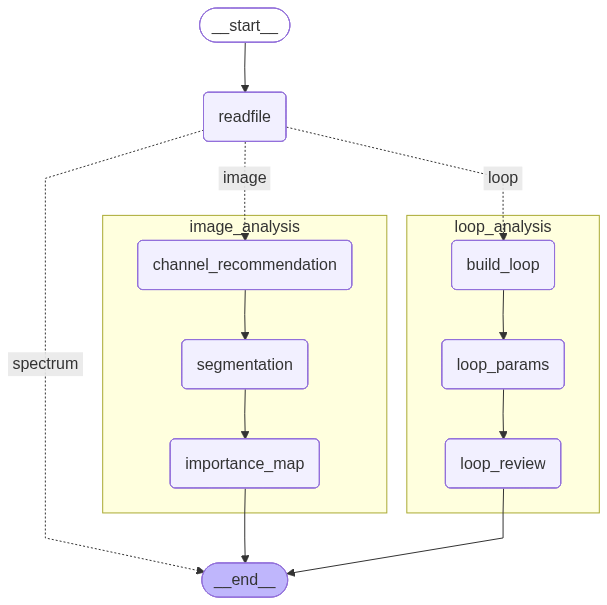

In [3]:
from IPython.display import Image
Image(im_graph.get_graph(xray=True).draw_mermaid_png())

In [4]:
scan_res = await im_graph.ainvoke({"file_path": r"/Users/borisslautin/Documents/!!UTK/agentic_SPM/exp_files/PLZT_0001.ibw",
                              "experiment_tasks": EXPERIMENT_TASKS,
                              "experiment_context": EXPERIMENT_CONTEXT
                              })
loop_res = await im_graph.ainvoke({"file_path": r"/Users/borisslautin/Downloads/PLZT/PLZT_0005.ibw"})

image
loop


In [16]:
# 2. artificially combine into experiment records
scan_rec = {**scan_res, "scan_index": 0}                       # kind="image" already set by readfile
loop_recs = [
    {**loop_res, "scan_index": 0, "pixel_yx": (120, 45)},      # kind="loop" already set
    {**loop_res, "scan_index": 0, "pixel_yx": (30, 200)},      # same loop, different fake spots —
    {**loop_res, "scan_index": 0, "pixel_yx": (128, 128)},     # enough to test formatting & phi
]
state = {
    "experimental_records": [scan_rec, *loop_recs]
         }

In [17]:
state

{'experimental_records': [{'file_path': '/Users/borisslautin/Documents/!!UTK/agentic_SPM/exp_files/PLZT_0001.ibw',
   'file_channels': {'Channel_000': {'title': 'HeightRetrace',
     'units': 'm',
     'data_type': 'IMAGE',
     'shape': [256, 256],
     'stats': {'ok': True,
      'min': -4.108699158678064e-09,
      'max': 6.594916612812085e-09,
      'mean': -8.413408858487514e-17,
      'std': 1.868449575889247e-09,
      'p01': -2.8537556318042336e-09,
      'p99': 4.834470246350975e-09},
     'preview_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/HeightRetrace.png',
     'array_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/HeightRetrace.npy'},
    'Channel_001': {'title': 'Amplitude1Retrace',
     'units': 'm',
     'data_type': 'IMAGE',
     'shape': [256, 256],
     'stats': {'ok': True,
      'min': 9.537324922870294e-12,
      'max': 1.3852193003760505e-10,
      'mean': 4.35912641778722

EXPERIMENT TASK: Compare switching inside domains vs near domain walls

MEASURED RESULTS

Scan_0 (current)
  criteria (weight — rationale):
    - wall_proximity (0.26) — Inverse distance to domain wall (from wall segmentation EDT): high score at wall pixels enables sampling of wall-mediated switching, which is mechanistically distinct from bulk switching due to pinning, depolarization fields, and reduced coercive field at the wall.
    - domain_interior_depth (0.26) — Distance from nearest wall within domain-segmented regions: high score deep inside domains provides reference measurements of intrinsic bulk switching behavior, far from wall-induced perturbations, enabling a clean domain vs. wall comparison.
    - pfm_amplitude (0.17) — Mean DART-PFM amplitude (avg of f1 and f2 drives): higher piezoelectric amplitude indicates stronger electromechanical coupling and better signal-to-noise ratio for local switching spectroscopy (PFM hysteresis loops), reducing uncertainty in coercive fiel

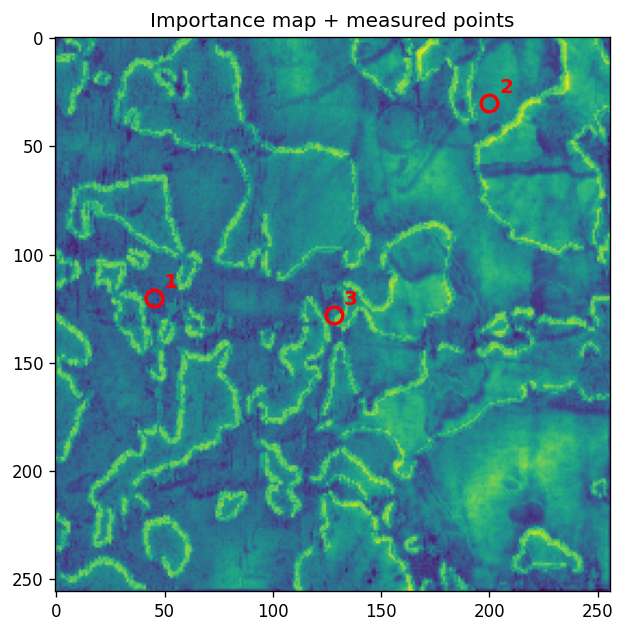

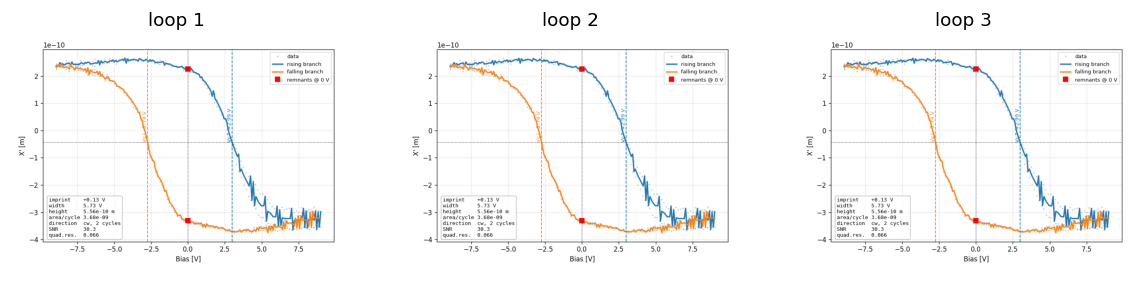

In [21]:
# 3. build and inspect the digest
from pathlib import Path
from spm_agent.utils.decision_utils import build_decision_digest

from spm_agent.config import decisions_dir

k = len(state.get("decision_records", []))
work_dir = decisions_dir() / f"decision_{k:02d}"
work_dir.mkdir(parents=True, exist_ok=True)
content = build_decision_digest(state, work_dir=work_dir)
(work_dir / "digest.txt").write_text(content[0]["text"])

print(content[0]["text"])                                      # the text the decider will see

from IPython.display import Image as IImage, display
display(IImage(str(work_dir / "digest_map.png")))
if (work_dir / "digest_loops.png").exists():
    display(IImage(str(work_dir / "digest_loops.png")))

AttributeError: 'list' object has no attribute 'keys'

In [ ]:
# from langchain_core.messages import SystemMessage
# from spm_agent.utils.message_utils import with_context

# DECISION_SYSTEM_PROMPT = (
#     "You are the experimentalist running an automated PFM study. You receive a digest of "
#     "everything measured so far: for each scan, its importance-map criteria (weights and "
#     "physical rationale) and segmentation summary; for each hysteresis loop, its location, "
#     "per-criterion importance at that location ('at:'), extracted parameters, quality "
#     "review, and interpretation. Figures show the current scan's importance map with the "
#     "measured points, and the loops themselves.\n\n"

#     "Review the evidence like a scientist at the microscope, not a scheduler: what do we "
#     "now know about the task? What is surprising or inconsistent? Which criteria are well "
#     "sampled and which are undersampled or unresolved? Is there an open question one more "
#     "loop could close — or has the current image told us what it can?\n\n"

#     "Then choose exactly one action:\n"
#     "  loop — one more hysteresis loop on the current scan; set target_criterion to the "
#     "criterion it should serve, copied exactly from the CRITERIA line. The measurement "
#     "location is chosen by a separate deterministic procedure — never propose coordinates.\n"
#     "  scan — acquire a new image: the current one is exhausted or compromised.\n"
#     "  stop — the task is answered consistently, or further measurement adds nothing.\n\n"

#     "Base every claim only on the digest; cite loop numbers and values. Do not assume "
#     "measurements that are not listed."
# )

# def build_decision_system_message(ctx=None) -> SystemMessage:
#     return SystemMessage(content=with_context(DECISION_SYSTEM_PROMPT, ctx))

In [30]:
from pprint import pprint

pprint(build_decision_system_message(ctx=EXPERIMENT_CONTEXT).content)

('You are the experimentalist running an automated PFM study. You receive a '
 'digest of everything measured so far: for each scan, its importance-map '
 'criteria (weights and physical rationale) and segmentation summary; for each '
 'hysteresis loop, its location, per-criterion importance at that location '
 "('at:'), extracted parameters, quality review, and interpretation. Figures "
 "show the current scan's importance map with the measured points, and the "
 'loops themselves.\n'
 '\n'
 'Review the evidence like a scientist at the microscope, not a scheduler: '
 'what do we now know about the task? What is surprising or inconsistent? '
 'Which criteria are well sampled and which are undersampled or unresolved? Is '
 'there an open question one more loop could close — or has the current image '
 'told us what it can?\n'
 '\n'
 'Then choose exactly one action:\n'
 '  loop — one more hysteresis loop on the current scan; set target_criterion '
 'to the criterion it should serve, copi

In [ ]:
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage

from spm_agent.config import SEG_MODEL, SEG_MAX_TOKENS, decisions_dir
from spm_agent.schemas.experimental_decision import ExperimentDecision
from spm_agent.states.pfm_experiment_state import PFMExperimentState
from spm_agent.utils.decision_utils import build_decision_digest
from spm_agent.nodes.decision_node import experiment_decision_node



In [37]:
# # 4. decision on scan-only evidence (expect: action="loop" + a criterion)
# from spm_agent.nodes.experiment_decision_node import experiment_decision_node

upd = await experiment_decision_node({"experimental_records": [scan_rec]})
d0 = upd["decision_records"][-1]
print(d0.action, "|", d0.target_criterion)
print("U:", d0.understanding, "\nQ:", d0.open_questions, "\nR:", d0.reasoning)

loop | wall_proximity
U: No hysteresis loops have been measured yet on Scan_0. The importance map clearly shows the domain wall network (bright yellow-green lines) and domain interiors (teal/blue regions), with 61% domain area across 2 regions and 14% wall area across 91 regions. The two highest-weighted criteria (wall_proximity and domain_interior_depth, each 0.26) directly serve the core task of comparing switching at walls vs. domain interiors. 
Q: All switching parameters (coercive field, nucleation bias, saturation amplitude, loop shape) are completely unknown — no loops have been measured anywhere on this scan. We need measurements at both wall-proximal and domain-interior locations to make any comparison. 
R: Zero loops have been collected so far, making every aspect of the task unanswered. The highest-priority criterion is wall_proximity (weight 0.26), which directly targets the wall-mediated switching behavior that is the first half of the domain-vs-wall comparison. Starting h

In [38]:
# 5. decision on scan + 3 loops (the full artificial state)
upd = await experiment_decision_node(state)
d1 = upd["decision_records"][-1]
print(d1.action, "|", d1.target_criterion)
print("U:", d1.understanding, "\nQ:", d1.open_questions, "\nR:", d1.reasoning)
state.update(upd)              # apply, so a repeated call writes decision_01, not 00

loop | wall_proximity
U: All three loops (1, 2, 3) show identical extracted parameters (Vc +2.99V/-2.74V, width 5.73V, imprint +0.126V, height 5.56e-10), which is a strong red flag — these are likely the same measurement repeated or a data pipeline artifact rather than three independent measurements. Despite this, the loops were taken at locations spanning a range of wall_proximity (0.10–0.48) and domain_interior_depth (0.06–0.24), which is exactly the contrast needed for the task. Loop 2 at px(30,200) has the highest domain_interior_depth (0.24) and pfm_amplitude (0.93), representing deep domain interior. Loop 3 at px(128,128) has the highest wall_proximity (0.48), representing near-wall switching. Loop 1 at px(120,45) is intermediate in both criteria. 
Q: The identical parameters across all three loops make it impossible to draw any meaningful comparison between domain interior vs. wall switching — the core task is unresolved. We need at least one more loop with high wall_proximity (

In [40]:
upd_g = await experiment_decision_node({"experimental_records": []})
print("guard:", upd_g["decision_records"][-1].action)          # -> "scan", no LLM call

from spm_agent.utils.decision_utils import resolve_criterion
meta = scan_rec["importance_maps"][0]["components_meta"]
print("resolved:", resolve_criterion(d1, meta.names))          # exact name or None

guard: scan
resolved: wall_proximity


In [41]:
upd_g["decision_records"]

[ExperimentDecision(understanding='(deterministic guard)', open_questions='', action='scan', target_criterion=None, reasoning='No image measured yet; a scan is required first.')]